<a href="https://colab.research.google.com/github/Sujal9858/SujalGit/blob/main/fake_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
#Logistic Regression Classifier
#Glen Mason
#Week 3 MOD008912


In [19]:
#Declare Reference to General Libraries
import pandas as pd #Used to manipulate data sets (derived from PaNel DAta) pd is a short alias.
import numpy as np #Used to work with Arrays (e.g. useful in manual I/O validation)
import matplotlib.pyplot as plt #Used to generate statisticals e.g. graphs
import seaborn as sns #A more sophisticated version of matplotlib illustration
#Import Special Data Analysis Packages
from sklearn.model_selection import train_test_split #Used to split Data Set
from sklearn.linear_model import LogisticRegression #Selected Modelling Algorithim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


Rows Columns
(887, 8)
   Passenger Class  Female  Male   Age  Siblings/Spouses Aboard  \
0                3       0     1  22.0                        1   
1                1       1     0  38.0                        1   
2                3       1     0  26.0                        0   
3                1       1     0  35.0                        1   
4                3       0     1  35.0                        0   

   Parents/Children Aboard     Fare  Survived  
0                        0   7.2500         0  
1                        0  71.2833         1  
2                        0   7.9250         1  
3                        0  53.1000         1  
4                        0   8.0500         0  

 Survived
0    545
1    342
Name: count, dtype: int64


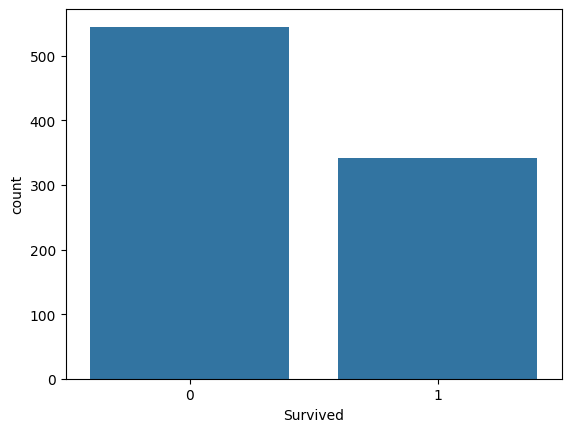

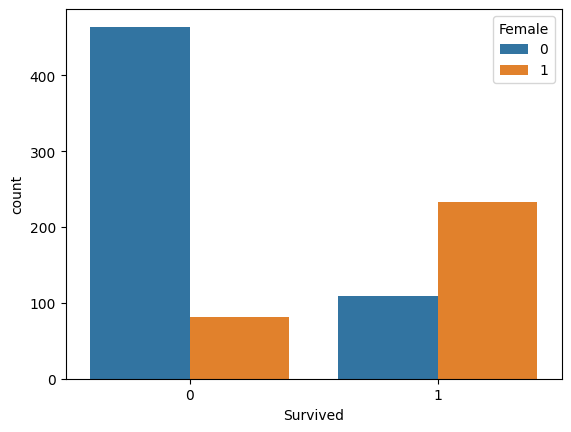

In [30]:
#Read and Display Data Set
#First, read in CSV file and assign it to a variable called "data"
data = pd.read_csv('titanic.csv')
#Second, display maximum rows and columns
print('\nRows Columns') #indicates rows and columns
print(data.shape) #gets the number rows and columns of data set
#Third, display first 5 x rows to check data
print(data.head(5))
#Select the last column (assuming the last column is the class)
last_column = data.iloc[:, -1] #using iloc to select the last column
#Count occurances of 0's and 1's
value_counts = last_column.value_counts()
#Print the counts and check for class imbalance
print('\n',value_counts)
sns.countplot(x='Survived',data=data)
plt.show()
plt.clf()
sns.countplot(x='Survived', hue = 'Female', data=data)
plt.show()

Axes(0.125,0.11;0.62x0.77)


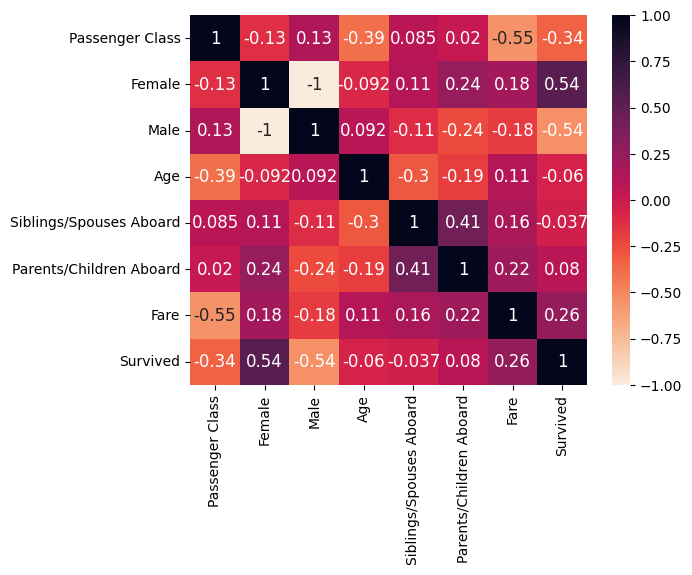

In [24]:
#Display Feature Relations of Data Set
print(sns.heatmap(data.corr(),annot=True, annot_kws={"size":12}, cmap = sns.cm.rocket_r))

In [25]:
#Declare X and Y Variables and Split the DataSet into Train and Test sections
X=data.drop(['Survived'],axis=1).values #X variables = all columns except last one
#Declare last column to be the dependednt Y variable
y=data['Survived']
#Split Data Set 70% Training and 30% Testing. Initial data shuffle set to Zero.
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.7,test_size = 0.3,random_state=0)

In [26]:
#Create and Test the Model
#First declare a new model
classifier_model = LogisticRegression(max_iter=10000)
#Second Train (fit) the model from the training data
classifier_model.fit(X_train,y_train)
#Third get Coefficients
print('\nIntercept = ',classifier_model.intercept_) #Find Bias Intercept
print('\nCoefficients = ',classifier_model.coef_) #Find Weightings (Gradients) of features
#Fourth make some predictions
y_pred = classifier_model.predict(X_test)
print('\nTest Data Model Predictions',y_pred)


Intercept =  [3.85018122]

Coefficients =  [[-1.13916938e+00  1.38069702e+00 -1.38055897e+00 -4.45207075e-02
  -3.62494336e-01 -1.07464650e-01  1.36269822e-03]]

Test Data Model Predictions [1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 1 1 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1
 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 1 1
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 1
 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 1 0 0
 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 1 1 1 1 0
 1 1 0 0 0 1 0 1 1 1 0 1 0 1 0 0 0 1 1 1 0 1 0 1 0 1 0 1 0 0 0 0 1 0 1 0 0
 1 0 1 0 1 0 0 1]


In [27]:
#Evaluate the Model:Display Confusion Matrix and Performance Metrics
print("\nConfusion Matrix: \n", confusion_matrix(y_test, y_pred))
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
#Display the performance metrics
print("\nEvaluation Metrics")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")



Confusion Matrix: 
 [[141  21]
 [ 34  71]]

Evaluation Metrics
Accuracy: 0.79
Precision: 0.77
Recall: 0.68
F1 Score: 0.72


In [33]:
#Validate the model with Own (Unseen) Test Data
Titanic_Survival = []
print("\nEnter values for independent variables:")
print("For Passesnger Class enter 1, 2 or 3")
print("For Female enter 1 or 0")
print("For Male enter 1 or 0")
print("For Age enter Age")
print("For Siblings/Spouses Aboard enter whole number")
print("For Parents/Children Aboard enter whole number")
print("For the Fare enter decimal number")
#Collect user input for each feature by:
#Retrieve column names from data frame
#Read in user input
#Write and update list
for i, column_name in enumerate(data.columns[:-1]):
    value = float(input(f"{column_name}: "))
    Titanic_Survival.append(value)
#Convert data to a numpy array and reshape it to (1, -1) 2D Array
Titanic_Survival = np.array(Titanic_Survival).reshape(1, -1)
#Predict the price using the logistic regression classifier model
predicted_survival = classifier_model.predict(Titanic_Survival)
print(f"\nSurvived: {predicted_survival[0]}")


Enter values for independent variables:
For Passesnger Class enter 1, 2 or 3
For Female enter 1 or 0
For Male enter 1 or 0
For Age enter Age
For Siblings/Spouses Aboard enter whole number
For Parents/Children Aboard enter whole number
For the Fare enter decimal number
Passenger Class: 1
Female: 1
Male: 0
Age: 30
Siblings/Spouses Aboard: 0
Parents/Children Aboard: 0
Fare: 80.0

Survived: 1
